In [2]:
import pandas as pd

# Load Solana dataset
df = pd.read_csv("Solana_Price_data.csv")

# Display dataset
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (1368, 6)

Columns:
Index(['time', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='str')

First 5 Rows:
         time   Open   High    Low  Close      Volume
0  2021-01-01  1.510  1.865  1.495  1.847  1125773.54
1  2021-01-02  1.847  2.012  1.752  1.799  1060347.35
2  2021-01-03  1.799  2.808  2.007  2.185  1475936.63
3  2021-01-04  2.185  2.573  2.066  2.491  1543191.05
4  2021-01-05  2.491  2.634  2.145  2.158  1246011.66


In [3]:
from sklearn.preprocessing import StandardScaler

# Select ML features
X = df[["Open", "High", "Low", "Close", "Volume"]]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original data shape:", X.shape)
print("Scaled data shape:", X_scaled.shape)

Original data shape: (1368, 5)
Scaled data shape: (1368, 5)


In [4]:
from sklearn.cluster import KMeans

# K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

print(df[[
    "time",
    "Close",
    "Volume",
    "KMeans_Cluster"
]].head(20))

          time  Close      Volume  KMeans_Cluster
0   2021-01-01  1.847  1125773.54               2
1   2021-01-02  1.799  1060347.35               2
2   2021-01-03  2.185  1475936.63               2
3   2021-01-04  2.491  1543191.05               2
4   2021-01-05  2.158  1246011.66               2
5   2021-01-06  1.925  1235109.61               2
6   2021-01-07  2.360  1657680.12               2
7   2021-01-08  3.225  2032046.03               2
8   2021-01-09  3.381   938188.86               2
9   2021-01-10  3.471   662473.96               2
10  2021-01-11  3.118  1187947.45               2
11  2021-01-12  3.737  1005517.84               2
12  2021-01-13  3.647   676796.96               2
13  2021-01-14  3.326   691711.54               2
14  2021-01-15  3.245   574281.91               2
15  2021-01-16  3.449   463418.94               2
16  2021-01-17  3.824   697433.44               2
17  2021-01-18  3.798   854065.36               2
18  2021-01-19  3.635   840275.37               2


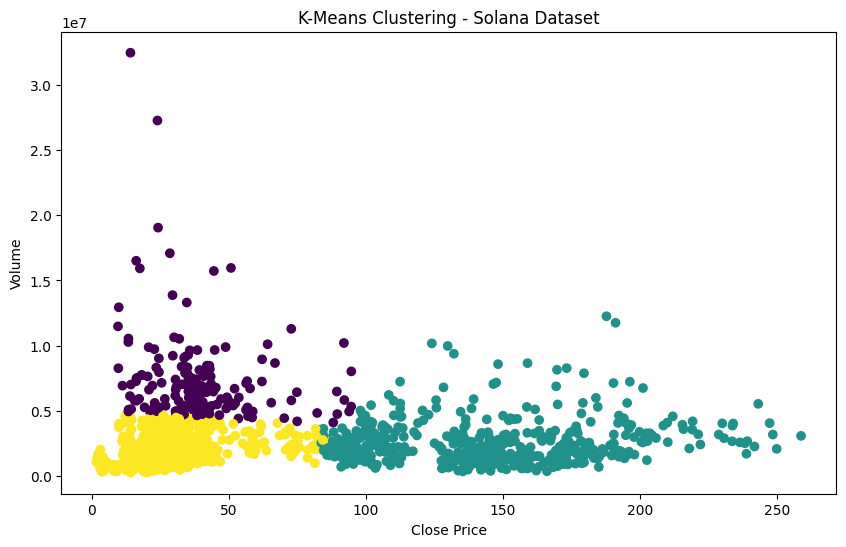

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Close"],
    df["Volume"],
    c=df["KMeans_Cluster"]
)

plt.xlabel("Close Price")
plt.ylabel("Volume")
plt.title("K-Means Clustering - Solana Dataset")

plt.show()

In [6]:
from sklearn.cluster import DBSCAN

# DBSCAN
dbscan = DBSCAN(
    eps=0.9,
    min_samples=2
)

# Apply DBSCAN to scaled data
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

# Display result
print("DBSCAN Result:")
print(df[[
    "time",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "DBSCAN_Cluster"
]].head(20))

DBSCAN Result:
          time   Open   High    Low  Close      Volume  DBSCAN_Cluster
0   2021-01-01  1.510  1.865  1.495  1.847  1125773.54               0
1   2021-01-02  1.847  2.012  1.752  1.799  1060347.35               0
2   2021-01-03  1.799  2.808  2.007  2.185  1475936.63               0
3   2021-01-04  2.185  2.573  2.066  2.491  1543191.05               0
4   2021-01-05  2.491  2.634  2.145  2.158  1246011.66               0
5   2021-01-06  2.158  2.628  1.895  1.925  1235109.61               0
6   2021-01-07  1.958  2.652  1.939  2.360  1657680.12               0
7   2021-01-08  2.360  3.815  2.182  3.225  2032046.03               0
8   2021-01-09  3.225  3.681  2.932  3.381   938188.86               0
9   2021-01-10  3.381  3.762  3.165  3.471   662473.96               0
10  2021-01-11  3.471  3.516  2.599  3.118  1187947.45               0
11  2021-01-12  3.118  3.919  3.084  3.737  1005517.84               0
12  2021-01-13  3.737  4.175  3.263  3.647   676796.96        

In [7]:
# -1 means outlier
outliers = df[df["DBSCAN_Cluster"] == -1]

print("Number of outliers:", len(outliers))

print("\nOutliers:")
print(outliers[[
    "time",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]])

Number of outliers: 3

Outliers:
           time   Open   High    Low  Close       Volume
388  2022-01-24  99.81  99.89  80.79  91.99  10200729.81
676  2022-11-08  29.62  31.63  21.50  24.02  27262061.11
677  2022-11-09  24.02  24.03  12.08  14.17  32460754.83


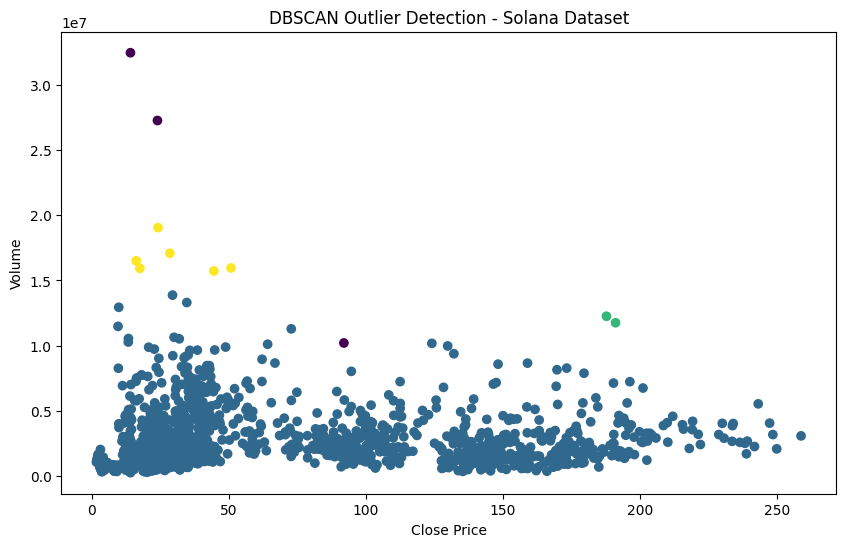

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Close"],
    df["Volume"],
    c=df["DBSCAN_Cluster"]
)

plt.xlabel("Close Price")
plt.ylabel("Volume")
plt.title("DBSCAN Outlier Detection - Solana Dataset")

plt.show()

In [9]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import BernoulliRBM

# Select features
X = df[["Open", "High", "Low", "Close", "Volume"]]

# Normalize data between 0 and 1
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

# RBM
rbm = BernoulliRBM(
    n_components=2,
    learning_rate=0.01,
    n_iter=300,
    random_state=42
)

# Train RBM
rbm.fit(X_norm)

# Generate hidden features
hidden = rbm.transform(X_norm)

# Add hidden features to dataset
df["Hidden1"] = hidden[:, 0]
df["Hidden2"] = hidden[:, 1]

# Display result
print("RBM Result:")
print(df[[
    "time",
    "Close",
    "Volume",
    "Hidden1",
    "Hidden2"
]].head(20))

RBM Result:
          time  Close      Volume   Hidden1   Hidden2
0   2021-01-01  1.847  1125773.54  0.533407  0.534603
1   2021-01-02  1.799  1060347.35  0.532966  0.534160
2   2021-01-03  2.185  1475936.63  0.532149  0.533340
3   2021-01-04  2.491  1543191.05  0.531839  0.533028
4   2021-01-05  2.158  1246011.66  0.531732  0.532921
5   2021-01-06  1.925  1235109.61  0.532244  0.533435
6   2021-01-07  2.360  1657680.12  0.532107  0.533297
7   2021-01-08  3.225  2032046.03  0.530490  0.531674
8   2021-01-09  3.381   938188.86  0.529323  0.530501
9   2021-01-10  3.471   662473.96  0.528936  0.530112
10  2021-01-11  3.118  1187947.45  0.529685  0.530864
11  2021-01-12  3.737  1005517.84  0.528930  0.530106
12  2021-01-13  3.647   676796.96  0.528290  0.529463
13  2021-01-14  3.326   691711.54  0.528797  0.529972
14  2021-01-15  3.245   574281.91  0.529299  0.530476
15  2021-01-16  3.449   463418.94  0.528996  0.530172
16  2021-01-17  3.824   697433.44  0.528436  0.529610
17  2021-01-18  

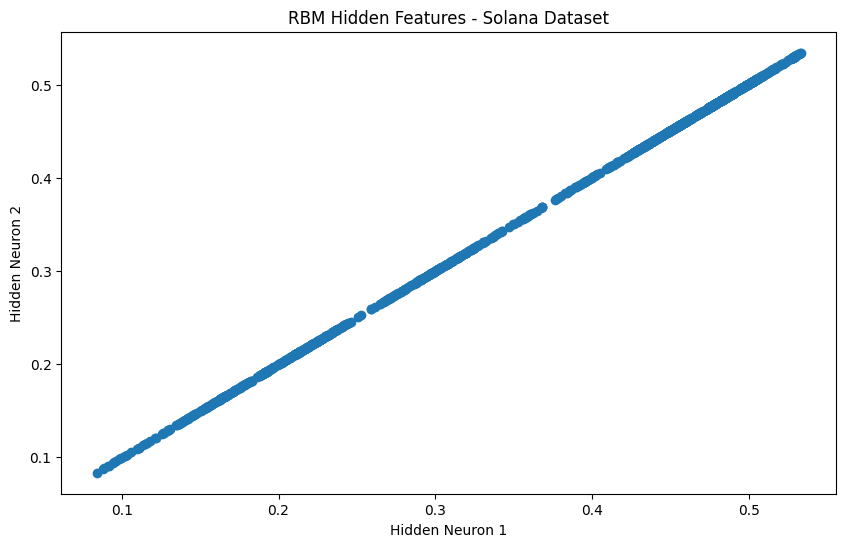

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Hidden1"],
    df["Hidden2"]
)

plt.xlabel("Hidden Neuron 1")
plt.ylabel("Hidden Neuron 2")
plt.title("RBM Hidden Features - Solana Dataset")

plt.show()

In [11]:
# Final combined result

result = df[[
    "time",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "KMeans_Cluster",
    "DBSCAN_Cluster",
    "Hidden1",
    "Hidden2"
]]

print("Final Dataset:")
print(result.head(20))

print("\nDataset Shape:")
print(result.shape)

# Save final results
result.to_csv(
    "Solana_ML_Results.csv",
    index=False
)

print("\nSaved successfully as:")
print("Solana_ML_Results.csv")

Final Dataset:
          time   Open   High    Low  Close      Volume  KMeans_Cluster  \
0   2021-01-01  1.510  1.865  1.495  1.847  1125773.54               2   
1   2021-01-02  1.847  2.012  1.752  1.799  1060347.35               2   
2   2021-01-03  1.799  2.808  2.007  2.185  1475936.63               2   
3   2021-01-04  2.185  2.573  2.066  2.491  1543191.05               2   
4   2021-01-05  2.491  2.634  2.145  2.158  1246011.66               2   
5   2021-01-06  2.158  2.628  1.895  1.925  1235109.61               2   
6   2021-01-07  1.958  2.652  1.939  2.360  1657680.12               2   
7   2021-01-08  2.360  3.815  2.182  3.225  2032046.03               2   
8   2021-01-09  3.225  3.681  2.932  3.381   938188.86               2   
9   2021-01-10  3.381  3.762  3.165  3.471   662473.96               2   
10  2021-01-11  3.471  3.516  2.599  3.118  1187947.45               2   
11  2021-01-12  3.118  3.919  3.084  3.737  1005517.84               2   
12  2021-01-13  3.737  

In [12]:
print("========== FINAL RESULTS ==========")

print("\nK-Means:")
print(df["KMeans_Cluster"].value_counts().sort_index())

print("\nDBSCAN:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

print("\nRBM:")
print(df[["Hidden1", "Hidden2"]].head())

========== FINAL RESULTS ==========

K-Means:
KMeans_Cluster
0    177
1    517
2    674
Name: count, dtype: int64

DBSCAN:
DBSCAN_Cluster
-1       3
 0    1357
 1       2
 2       6
Name: count, dtype: int64

RBM:
    Hidden1   Hidden2
0  0.533407  0.534603
1  0.532966  0.534160
2  0.532149  0.533340
3  0.531839  0.533028
4  0.531732  0.532921
